[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoAvancadoIME/blob/main/05_regularizacao.ipynb)

# Aula 5 - Regularização de Problemas Inversos

**Maj Diego - 1º Semestre / 2027**

**Objetivos:**

1. Reconhecer problemas mal condicionados.
2. Aplicar TSVD e regularização de Tikhonov.
3. Comparar viés, variância e estabilidade e preparar a 4ª VE prática.

## 1. Problemas mal postos

Valores singulares pequenos amplificam o ruído. A regularização troca parte da resolução por estabilidade, incorporando um corte espectral ou uma preferência sobre a solução.

## 2. TSVD

Se $A=U\Sigma V^T$, o TSVD mantém apenas $k$ valores singulares: $x_k=V_k\Sigma_k^{-1}U_k^TL$.

In [ ]:
import numpy as np

A = np.array([[1., .99], 
              [.99, .9802], 
              [1.01, 1.]])
L = np.array([2.01, 1.98, 2.02])
U, s, Vt = np.linalg.svd(A, full_matrices=False)
for k in (1, 2):
    x_tsvd = Vt[:k].T @ ((U[:, :k].T @ L) / s[:k])
    print('k=', k, 'x=', x_tsvd)

k= 1 x= [1.01166581 1.00161659]
k= 2 x= [100.99020196 -99.980004  ]


## 3. Tikhonov

A solução $x_\lambda=(A^TA+\lambda^2R^TR)^{-1}A^TL$ penaliza soluções incompatíveis com $R$. O parâmetro $\lambda$ controla o compromisso entre ajuste e estabilidade.

In [2]:
for lam in (0., .01, .1, 1.):
    x = np.linalg.solve(A.T@A + lam**2*np.eye(2), A.T@L)
    print(f'lambda={lam:>4}: x={x}, ||v||={np.linalg.norm(A@x-L):.4f}')

lambda= 0.0: x=[100.99020341 -99.98000546], ||v||=0.0001
lambda=0.01: x=[1.015015   0.99819974], ||v||=0.0082
lambda= 0.1: x=[1.0099995  0.99989951], ||v||=0.0101
lambda= 1.0: x=[0.86591591 0.8573138 ], ||v||=0.5000


## 4ª VE prática

Resolver um problema inverso sintético por solução direta, TSVD e Tikhonov; justificar $k$ e $\lambda$ por diagnóstico gráfico ou validação e discutir estabilidade.

### Questão — rede altimétrica com ligação fraca entre dois setores

Uma barragem possui seis marcos de controle. O **setor 1** contém A, B e C; o **setor 2**, D, E e F. Foram obtidos desníveis por nivelamento geométrico dentro de cada setor, mas não foi possível realizar nivelamento entre os setores. As duas ligações disponíveis, A → D e C → D, vêm de um levantamento de reconhecimento por GNSS e têm precisão muito inferior.

A referência **A tem altitude fixa e exata de 150,000 m**. As observações GNSS já foram expressas no mesmo referencial altimétrico do nivelamento. Para este exercício, admita medições independentes, realizadas na mesma época, e os desvios-padrão conhecidos da tabela. Todos os dados são **sintéticos, para fins didáticos**.

**Cotas aproximadas, usadas como referência da regularização**

| Marco | A (fixo) | B | C | D | E | F |
|---|---:|---:|---:|---:|---:|---:|
| Altitude H⁰ (m) | 150,000 | 181,500 | 174,200 | 205,700 | 197,400 | 223,800 |

As cotas aproximadas podem conter erros. Usá-las como referência introduz informação prévia e pode produzir viés; elas não devem ser tratadas como novas observações exatas.

**Desníveis observados**

| Observação | De → para | Desnível observado (m) | σ (m) | Método |
|---|---|---:|---:|---|
| 1 | A → B | +31,535222 | 0,002 | Nivelamento geométrico |
| 2 | B → C | -7,360168 | 0,002 | Nivelamento geométrico |
| 3 | A → C | +24,173392 | 0,002 | Nivelamento geométrico |
| 4 | D → E | -8,394304 | 0,002 | Nivelamento geométrico |
| 5 | E → F | +26,462424 | 0,002 | Nivelamento geométrico |
| 6 | D → F | +18,069036 | 0,002 | Nivelamento geométrico |
| 7 | C → D | +30,601217 | 5,000 | Reconhecimento por GNSS |
| 8 | A → D | +51,336024 | 5,000 | Reconhecimento por GNSS |

Adote o sentido $\Delta h_{ij}=H_j-H_i$. Estime as correções

$$x=[\delta H_B,\delta H_C,\delta H_D,\delta H_E,\delta H_F]^T$$

em **mm**, com $\delta H_A=0$ e $H_j=H_j^0+\delta H_j/1000$ em metros. Para cada ligação, forme o termo observado reduzido

$$l_{ij}=1000\,[\Delta h_{ij}^{obs}-(H_j^0-H_i^0)],\qquad l+v=Ax.$$

Monte A com −1 na coluna do marco de partida e +1 na coluna do marco de chegada, omitindo a coluna de A. Converta os desvios-padrão para mm. Defina

$$D_\sigma=\operatorname{diag}(\sigma_i),\quad
\widetilde A=D_\sigma^{-1}A,\quad
\widetilde l=D_\sigma^{-1}l.$$

O branqueamento considera as precisões muito diferentes. A regularização deve atuar sobre as **correções às cotas aproximadas**, não sobre as altitudes absolutas.

**O que responder**

1. Formule o modelo e calcule os valores singulares de $\widetilde A$, seu posto, seu número de condição e o determinante da matriz normal. Interprete o determinante junto com o espectro singular, considerando sua dependência da escala. Explique qual movimento do setor 2 fica mal determinado. Verifique também o posto se as duas observações GNSS forem retiradas.
2. Calcule a solução de mínimos quadrados sem regularização usando todos os valores singulares. Mostre as correções e as altitudes ajustadas antes de compará-las com as soluções regularizadas. Evite a inversão explícita da matriz normal.
3. Aplique TSVD com $k=1,\ldots,5$ e Tikhonov de ordem zero, com $R=I$:
   $$\min_x\ \|\widetilde Ax-\widetilde l\|_2^2+\lambda^2\|x\|_2^2.$$
   Nesta formulação, $x$ está em mm e $\lambda$ em mm⁻¹.
4. Escolha k e λ sem consultar os valores usados para gerar as cotas. Use o princípio da discrepância com
   $$\delta=1{,}1\sqrt{8}.$$
   Para TSVD, selecione o **menor k** cujo resíduo ponderado tenha norma menor ou igual a δ. Para Tikhonov, selecione o **maior λ** que satisfaça o mesmo limite, na grade de 500 valores logarítmicos entre $10^{-6}$ e $10^1$ mm⁻¹. Justifique as escolhas com gráficos.
5. Compare altitudes, resíduos ponderados e normas das correções. Avalie a sensibilidade acrescentando uma perturbação $\Delta l_i=0{,}05\,\sigma_i z_i$, com $z_i\sim N(0,1)$ e semente 2028. Mantenha k e λ fixos nessa comparação.
6. Explique o viés introduzido pela regularização e proponha uma melhoria no levantamento. Discuta por que reduzir as oscilações numéricas não comprova que o setor 2 esteja estável.

O limite δ é uma regra de discrepância baseada no nível de ruído conhecido, com margem de 10%; não é um teste de hipótese com nível de significância especificado. A referência verdadeira da simulação será revelada apenas ao final da resolução, para avaliar o erro das soluções.


### Resolução — 4ª VE prática

**1. Modelo e diagnóstico do condicionamento**

Na ordem das observações da tabela e dos parâmetros B, C, D, E, F:

$$A=\begin{bmatrix}1 & 0 & 0 & 0 & 0 \\ -1 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 \\ 0 & 0 & -1 & 1 & 0 \\ 0 & 0 & 0 & -1 & 1 \\ 0 & 0 & -1 & 0 & 1 \\ 0 & -1 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0\end{bmatrix},\qquad l=\begin{bmatrix}35.222 \\ -60.168 \\ -26.608 \\ -94.304 \\ 62.424 \\ -30.964 \\ -898.783 \\ -4363.976\end{bmatrix}\ \mathrm{mm}.$$

Branqueiam-se as equações com $\widetilde A=D_\sigma^{-1}A$ e $\widetilde l=D_\sigma^{-1}l$. A SVD é $\widetilde A=U\operatorname{diag}(s_i)V^T$.

| Índice | Valor singular (mm⁻¹) |
| --- | --- |
| 1 | 0,866025441 |
| 2 | 0,866025409 |
| 3 | 0,866025404 |
| 4 | 0,500000020 |
| 5 | 0,000163299 |

O posto é **5**, com **8 − 5 = 3 graus de liberdade**. O número de condição de A branqueada é **5303,3** e o da matriz normal é aproximadamente **28125006**. As equações normais elevam ao quadrado o número de condição; por isso, a solução foi calculada pela SVD.

Para $N=\widetilde A^T\widetilde A$, calcula-se $\det(N)=\prod_i s_i^2$. Nesta escala, o resultado é **2.812500e-09 mm⁻¹⁰**, próximo de zero. O valor do determinante depende das unidades e da escala; o diagnóstico do mau condicionamento é sustentado pelo espectro singular e pelo número de condição, e não apenas por esse valor.

O último vetor singular direito, a menos de uma troca global de sinal, é:

$$v_{\min}=\begin{bmatrix}-0.000000 \\ -0.000000 \\ -0.577350 \\ -0.577350 \\ -0.577350\end{bmatrix}.$$

Essa direção corresponde principalmente a deslocar D, E e F juntos. Os desníveis internos do setor 2 quase não mudam com essa translação.

Sem as duas ligações GNSS, o posto cai para **4**: o setor 2 fica sem origem altimétrica determinada. Nesse caso, a matriz normal de ordem 5 é singular e não possui inversa. Com as ligações fracas, a inversa existe matematicamente, mas a informação sobre essa direção continua muito imprecisa.

**2. Solução direta, antes da regularização**

$$\hat x_{\mathrm{MMQ}}=V\operatorname{diag}(1/s_i)U^T\widetilde l.$$

Todos os valores singulares são usados. As correções são:

$$\hat x_{\mathrm{MMQ}}=\begin{bmatrix}34.668 \\ -26.054 \\ -2644.407 \\ -2738.405 \\ -2675.676\end{bmatrix}\ \mathrm{mm}.$$

| Marco | Altitude aproximada (m) | Correção MMQ (mm) | Altitude MMQ (m) |
| --- | --- | --- | --- |
| B | 181,500 | 34,668 | 181,534668 |
| C | 174,200 | -26,054 | 174,173946 |
| D | 205,700 | -2644,407 | 203,055593 |
| E | 197,400 | -2738,405 | 194,661595 |
| F | 223,800 | -2675,676 | 221,124324 |

A solução acomoda a baixa precisão das ligações com uma grande mudança conjunta das cotas do setor 2. Isso não é evidência suficiente de um deslocamento físico da barragem.

**3. Escolha de k e λ pelo princípio da discrepância**

$$x_k=V_k\operatorname{diag}(1/s_i)U_k^T\widetilde l,\qquad x_\lambda=V\operatorname{diag}\left(\frac{s_i}{s_i^2+\lambda^2}\right)U^T\widetilde l.$$

O limite é **δ = 3,111270**, adimensional. A escolha usa somente as observações e suas precisões.

| k | Norma do resíduo ponderado | Atende a δ? |
| --- | --- | --- |
| 1 | 40,661062 | Não |
| 2 | 38,548707 | Não |
| 3 | 3,223255 | Não |
| 4 | 1,055414 | Sim |
| 5 | 0,732572 | Sim |

O menor k admissível é **4**. Assim, a componente associada ao menor valor singular é descartada.

Na grade de 500 valores, o maior λ admissível é **0,176398 mm⁻¹**, com resíduo **2,979246**. O próximo λ, **0,182189 mm⁻¹**, produz resíduo **3,146184**, acima de δ. O resultado depende da grade e do limite de discrepância adotados.

**4. Comparação das cotas e dos resíduos**

| Marco | MMQ (m) | TSVD (m) | Tikhonov (m) |
| --- | --- | --- | --- |
| B | 181,534668 | 181,534668 | 181,532982 |
| C | 174,173946 | 174,173946 | 174,174679 |
| D | 203,055593 | 205,741756 | 205,740090 |
| E | 194,661595 | 197,347757 | 197,349836 |
| F | 221,124324 | 223,810487 | 223,810067 |

A permanece exatamente em 150,000 m nos três métodos.

| Ligação | v MMQ / σ | v TSVD / σ | v Tikhonov / σ |
| --- | --- | --- | --- |
| A → B | -0,277 | -0,277 | -1,120 |
| B → C | -0,277 | -0,277 | 0,932 |
| A → C | 0,277 | 0,277 | 0,643 |
| D → E | 0,153 | 0,153 | 2,025 |
| E → F | 0,153 | 0,153 | -1,097 |
| D → F | -0,153 | -0,153 | 0,470 |
| C → D | -0,344 | 0,193 | 0,193 |
| A → D | 0,344 | 0,881 | 0,881 |

| Método | Norma do resíduo ponderado | Norma das correções (mm) | Mudança da solução com perturbação (mm) |
| --- | --- | --- | --- |
| MMQ sem regularização | 0,732572 | 4653,265 | 162,212 |
| TSVD (k=4) | 1,055414 | 80,396 | 0,137 |
| Tikhonov (λ=0.176398 mm⁻¹) | 2,979246 | 77,162 | 0,123 |

A perturbação tem norma branqueada **0,157806**. Os três métodos recebem exatamente a mesma perturbação; k e λ permanecem fixos. A comparação mede a sensibilidade com esses hiperparâmetros, sem incluir a possível mudança na sua seleção.

**5. Interpretação geodésica e limitações**

O TSVD remove a direção pouco observável, o que mantém a correção comum do setor 2 próxima de zero em relação às cotas aproximadas. Tikhonov reduz continuamente a influência das direções pouco observáveis e também atenua parte das demais correções.

Essa estabilização usa as cotas aproximadas como referência. Se todo o setor 2 tiver sofrido um recalque real desde essa referência, a regularização poderá esconder parte dele. Uma solução estável pode ter viés; o menor resíduo também não garante as melhores cotas.

A melhoria prioritária é estabelecer uma ligação altimétrica precisa e independente entre os setores, com controle de fechamento e redundância, ou implantar referência confiável no setor 2. A regularização não substitui essa informação de campo.

**6. Conferência com a referência da simulação**

Semente 2027; correções verdadeiras de B, C, D, E e F: **[35; −25; 50; −40; 20] mm**. A matriz, os dados e as precisões foram usados na seleção; essas correções verdadeiras servem apenas para avaliar o resultado.

| Método | Erro da solução ‖x − x verdadeiro‖ (mm) |
| --- | --- |
| MMQ sem regularização | 4669,892 |
| TSVD (k=4) | 17,595 |
| Tikhonov (λ=0.176398 mm⁻¹) | 17,446 |

Os erros obtidos pertencem a esta realização do ruído; não demonstram superioridade universal de um método. A reprodução dos dados e as verificações numéricas passaram.

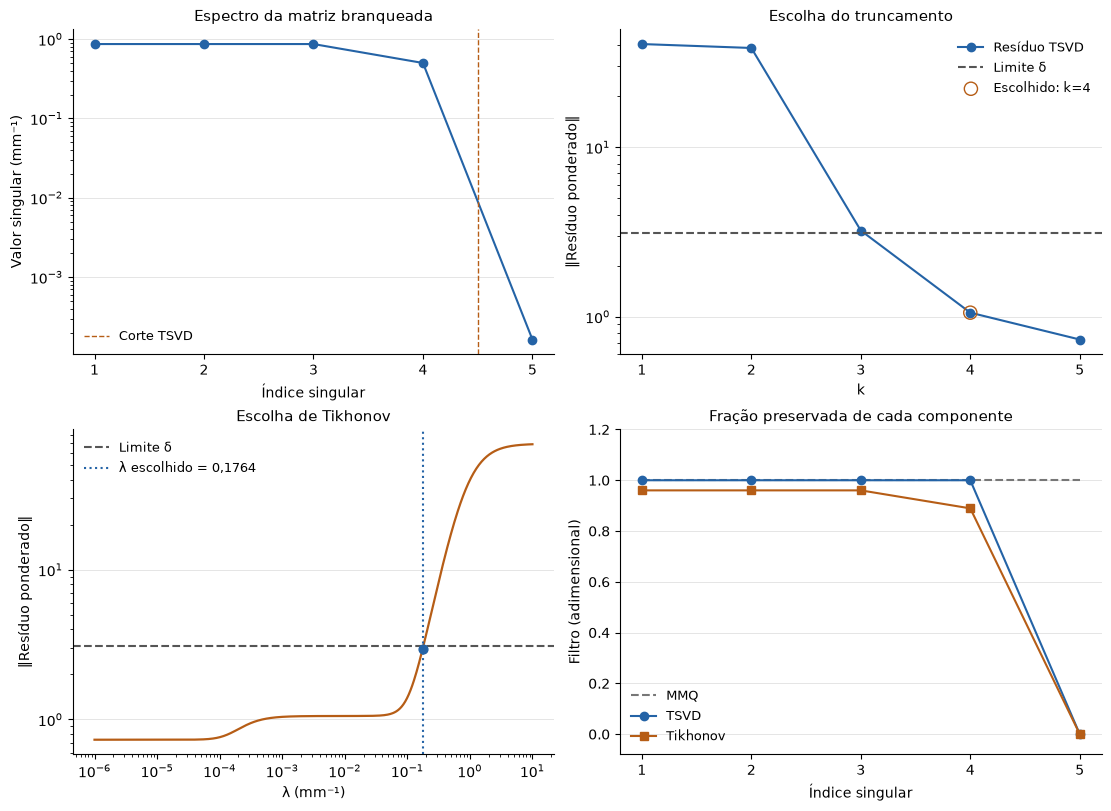

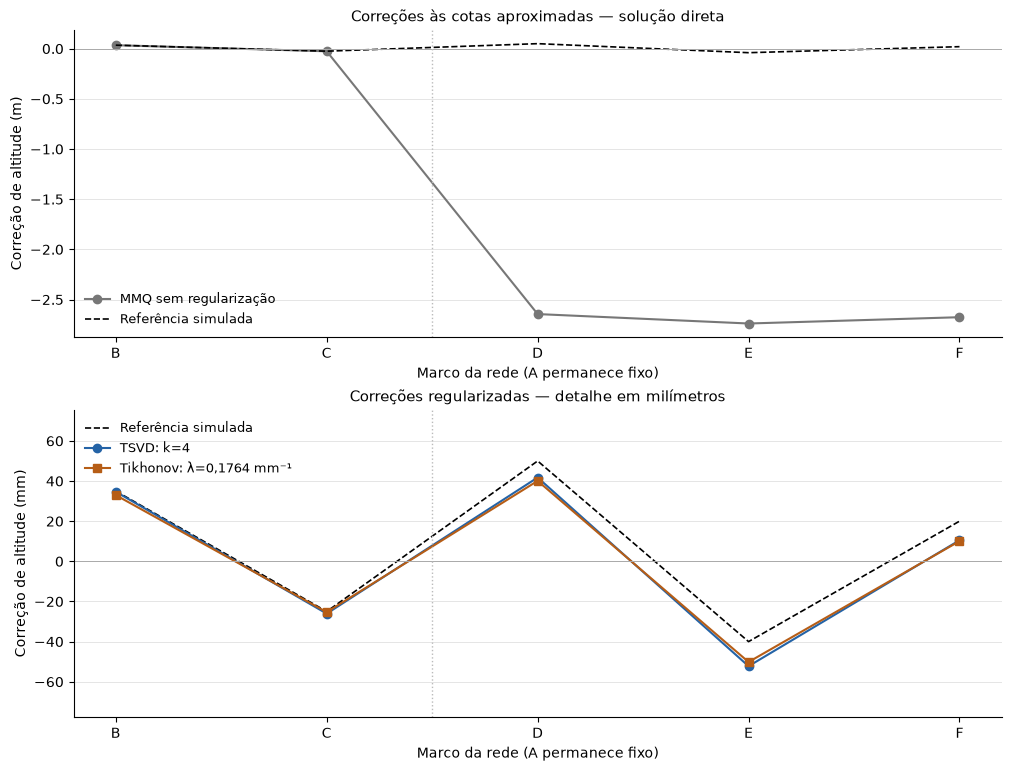

Nos gráficos das correções, o painel superior usa **metros** e o inferior usa **milímetros** para permitir a leitura das soluções regularizadas. A linha vertical separa B/C de D/E/F. As linhas entre os marcos apenas facilitam a comparação; não representam um perfil topográfico em escala.

In [3]:
# Resolução da 4ª VE prática — rede altimétrica de uma barragem
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def resolver_ve_regularizacao():
    nomes = np.array(list("ABCDEF"))
    H0 = np.array([150.,181.5,174.2,205.7,197.4,223.8])  # m
    ligacoes = [(0,1),(1,2),(0,2),(3,4),(4,5),(3,5),(2,3),(0,3)]
    L_m = np.array([31.535222, -7.360168, 24.173392, -8.394304, 26.462424, 18.069036, 30.601217000000002, 51.336023999999995])  # m, exatamente como na tabela
    sigma = np.array([2.,2.,2.,2.,2.,2.,5000.,5000.])  # mm
    A = np.zeros((8,5))
    for i,(origem,destino) in enumerate(ligacoes):
        if origem != 0:
            A[i,origem-1] = -1
        if destino != 0:
            A[i,destino-1] = 1
    diferencas_H0 = np.array([H0[j]-H0[i] for i,j in ligacoes])
    l = 1000*(L_m-diferencas_H0)
    Aw = A/sigma[:,None]
    lw = l/sigma
    U,s,Vt = np.linalg.svd(Aw,full_matrices=False)
    projecoes = U.T @ lw
    posto = np.linalg.matrix_rank(Aw)
    posto_sem_gnss = np.linalg.matrix_rank(A[:6])
    condicao = s[0]/s[-1]
    determinante_normal = np.exp(2*np.log(s).sum())

    # Solução direta de MMQ: todos os valores singulares, sem truncamento.
    x_direto = Vt.T @ (projecoes/s)
    x_lstsq = np.linalg.lstsq(Aw,lw,rcond=None)[0]

    # TSVD: testa todos os truncamentos possíveis, sem conhecer a verdade.
    ks = np.arange(1,6)
    solucoes_k = np.array([
        Vt[:k].T @ (projecoes[:k]/s[:k]) for k in ks
    ])
    residuos_k = np.linalg.norm(solucoes_k @ Aw.T-lw,axis=1)
    delta = 1.1*np.sqrt(len(l))
    candidatos_k = np.flatnonzero(residuos_k <= delta)
    if not len(candidatos_k):
        raise RuntimeError("Nenhum k atende à discrepância; revise os dados e o modelo.")
    indice_k = candidatos_k[0]
    k = int(ks[indice_k])
    x_tsvd = solucoes_k[indice_k]

    # Tikhonov: filtros espectrais equivalentes a R = I.
    lambdas = np.logspace(-6,1,500)  # mm^-1
    solucoes_lambda = (
        Vt.T @ (s[:,None]*projecoes[:,None]/
                 (s[:,None]**2+lambdas[None,:]**2))
    ).T
    residuos_lambda = np.linalg.norm(solucoes_lambda @ Aw.T-lw,axis=1)
    candidatos_lambda = np.flatnonzero(residuos_lambda <= delta)
    if not len(candidatos_lambda):
        raise RuntimeError("Nenhum lambda da grade atende à discrepância.")
    indice_lambda = candidatos_lambda[-1]
    lam = lambdas[indice_lambda]
    x_tikhonov = solucoes_lambda[indice_lambda]
    casos = [("MMQ sem regularização",x_direto),
             (f"TSVD (k={k})",x_tsvd),
             (f"Tikhonov (λ={lam:.6f} mm⁻¹)",x_tikhonov)]

    # Sensibilidade: perturbação comum, com hiperparâmetros mantidos fixos.
    perturbacao = 0.05*sigma*np.random.default_rng(2028).normal(size=len(l))
    perturbacao_w = perturbacao/sigma
    delta_projecoes = U.T @ perturbacao_w
    variacoes_x = [
        Vt.T @ (delta_projecoes/s),
        Vt[:k].T @ (delta_projecoes[:k]/s[:k]),
        Vt.T @ (s*delta_projecoes/(s**2+lam**2)),
    ]
    residuos = [A@x-l for _,x in casos]
    normas_residuo = [np.linalg.norm(v/sigma) for v in residuos]
    filtros_tsvd = (np.arange(len(s)) < k).astype(float)
    filtros_tikh = s**2/(s**2+lam**2)

    # Verificações independentes e propriedades relevantes do problema.
    assert posto == 5 and posto_sem_gnss == 4
    assert np.allclose(x_direto,x_lstsq,rtol=1e-9,atol=1e-7)
    assert np.allclose(Aw.T@(Aw@x_direto-lw),0,atol=1e-9)
    assert np.allclose(
        (Aw.T@Aw+lam**2*np.eye(5))@x_tikhonov,Aw.T@lw,atol=1e-9
    )
    assert np.all(np.diff(residuos_k) <= 1e-8)
    assert np.all(np.diff(residuos_lambda) >= -1e-8)
    assert residuos_k[indice_k] <= delta
    assert indice_k == 0 or residuos_k[indice_k-1] > delta
    assert 0 < indice_lambda < len(lambdas)-1
    assert residuos_lambda[indice_lambda+1] > delta

    def num(x,casas=6):
        return f"{x:.{casas}f}".replace(".",",")

    def matriz(M,casas=6):
        linhas=[" & ".join(f"{v:.{casas}f}" for v in linha)
                for linha in np.atleast_2d(M)]
        return r"\begin{bmatrix}"+r" \\ ".join(linhas)+r"\end{bmatrix}"

    def tabela(cabecalho,linhas):
        return "\n".join([
            "| "+" | ".join(cabecalho)+" |",
            "| "+" | ".join(["---"]*len(cabecalho))+" |",
            *["| "+" | ".join(map(str,linha))+" |" for linha in linhas],
        ])

    texto=[
        "### Resolução — 4ª VE prática",
        "**1. Modelo e diagnóstico do condicionamento**",
        "Na ordem das observações da tabela e dos parâmetros B, C, D, E, F:",
        "$$A="+matriz(A,0)+r",\qquad l="+matriz(l[:,None],3)+r"\ \mathrm{mm}.$$",
        r"Branqueiam-se as equações com $\widetilde A=D_\sigma^{-1}A$ "
        r"e $\widetilde l=D_\sigma^{-1}l$. A SVD é "
        r"$\widetilde A=U\operatorname{diag}(s_i)V^T$.",
        tabela(["Índice","Valor singular (mm⁻¹)"],
               [[i+1,num(si,9)] for i,si in enumerate(s)]),
        f"O posto é **{posto}**, com **8 − 5 = 3 graus de liberdade**. "
        f"O número de condição de A branqueada é **{num(condicao,1)}** "
        f"e o da matriz normal é aproximadamente **{num(condicao**2,0)}**. "
        "As equações normais elevam ao quadrado o número de condição; "
        "por isso, a solução foi calculada pela SVD.",
        r"Para $N=\widetilde A^T\widetilde A$, calcula-se "
        r"$\det(N)=\prod_i s_i^2$. Nesta escala, o resultado é "
        f"**{determinante_normal:.6e} mm⁻¹⁰**, próximo de zero. "
        "O valor do determinante depende das unidades e da escala; "
        "o diagnóstico do mau condicionamento é sustentado pelo espectro "
        "singular e pelo número de condição, e não apenas por esse valor.",
        "O último vetor singular direito, a menos de uma troca global de sinal, é:",
        r"$$v_{\min}="+matriz(Vt[-1][:,None],6)+".$$",
        "Essa direção corresponde principalmente a deslocar D, E e F juntos. "
        "Os desníveis internos do setor 2 quase não mudam com essa translação.",
        f"Sem as duas ligações GNSS, o posto cai para **{posto_sem_gnss}**: "
        "o setor 2 fica sem origem altimétrica determinada. Nesse caso, "
        "a matriz normal de ordem 5 é singular e não possui inversa. "
        "Com as ligações fracas, a inversa existe matematicamente, "
        "mas a informação sobre essa direção continua muito imprecisa.",
        "**2. Solução direta, antes da regularização**",
        r"$$\hat x_{\mathrm{MMQ}}=V\operatorname{diag}(1/s_i)U^T\widetilde l.$$",
        "Todos os valores singulares são usados. As correções são:",
        r"$$\hat x_{\mathrm{MMQ}}="+matriz(x_direto[:,None],3)+r"\ \mathrm{mm}.$$",
        tabela(["Marco","Altitude aproximada (m)","Correção MMQ (mm)","Altitude MMQ (m)"],
               [[nome,num(H0[i+1],3),num(x_direto[i],3),
                 num(H0[i+1]+x_direto[i]/1000)]
                for i,nome in enumerate(nomes[1:])]),
        "A solução acomoda a baixa precisão das ligações com uma grande "
        "mudança conjunta das cotas do setor 2. Isso não é evidência "
        "suficiente de um deslocamento físico da barragem.",
        "**3. Escolha de k e λ pelo princípio da discrepância**",
        r"$$x_k=V_k\operatorname{diag}(1/s_i)U_k^T\widetilde l,\qquad "
        r"x_\lambda=V\operatorname{diag}\left(\frac{s_i}{s_i^2+\lambda^2}\right)"
        r"U^T\widetilde l.$$",
        f"O limite é **δ = {num(delta)}**, adimensional. "
        "A escolha usa somente as observações e suas precisões.",
        tabela(["k","Norma do resíduo ponderado","Atende a δ?"],
               [[int(ki),num(ri),"Sim" if ri<=delta else "Não"]
                for ki,ri in zip(ks,residuos_k)]),
        f"O menor k admissível é **{k}**. Assim, a componente associada "
        "ao menor valor singular é descartada.",
        f"Na grade de 500 valores, o maior λ admissível é "
        f"**{num(lam)} mm⁻¹**, com resíduo **{num(residuos_lambda[indice_lambda])}**. "
        f"O próximo λ, **{num(lambdas[indice_lambda+1])} mm⁻¹**, "
        f"produz resíduo **{num(residuos_lambda[indice_lambda+1])}**, acima de δ. "
        "O resultado depende da grade e do limite de discrepância adotados.",
        "**4. Comparação das cotas e dos resíduos**",
        tabela(["Marco","MMQ (m)","TSVD (m)","Tikhonov (m)"],
               [[nome,*[num(H0[i+1]+x[i]/1000) for _,x in casos]]
                for i,nome in enumerate(nomes[1:])]),
        "A permanece exatamente em 150,000 m nos três métodos.",
        tabela(["Ligação","v MMQ / σ","v TSVD / σ","v Tikhonov / σ"],
               [[f"{nomes[fr]} → {nomes[to]}",
                 *[num(v[i]/sigma[i],3) for v in residuos]]
                for i,(fr,to) in enumerate(ligacoes)]),
        tabela(["Método","Norma do resíduo ponderado","Norma das correções (mm)",
                "Mudança da solução com perturbação (mm)"],
               [[nome,num(normas_residuo[i]),num(np.linalg.norm(x),3),
                 num(np.linalg.norm(variacoes_x[i]),3)]
                for i,(nome,x) in enumerate(casos)]),
        f"A perturbação tem norma branqueada **{num(np.linalg.norm(perturbacao_w))}**. "
        "Os três métodos recebem exatamente a mesma perturbação; k e λ "
        "permanecem fixos. A comparação mede a sensibilidade com esses "
        "hiperparâmetros, sem incluir a possível mudança na sua seleção.",
        "**5. Interpretação geodésica e limitações**",
        "O TSVD remove a direção pouco observável, o que mantém a correção "
        "comum do setor 2 próxima de zero em relação às cotas aproximadas. "
        "Tikhonov reduz continuamente a influência das direções pouco "
        "observáveis e também atenua parte das demais correções.",
        "Essa estabilização usa as cotas aproximadas como referência. "
        "Se todo o setor 2 tiver sofrido um recalque real desde essa referência, "
        "a regularização poderá esconder parte dele. Uma solução estável "
        "pode ter viés; o menor resíduo também não garante as melhores cotas.",
        "A melhoria prioritária é estabelecer uma ligação altimétrica precisa "
        "e independente entre os setores, com controle de fechamento e "
        "redundância, ou implantar referência confiável no setor 2. "
        "A regularização não substitui essa informação de campo.",
    ]
    display(Markdown("\n\n".join(texto)))

    # A verdade só entra depois da escolha de k e lambda.
    x_verdade = np.array([35.,-25.,50.,-40.,20.])
    ruido=np.random.default_rng(2027).normal(0,sigma)
    observacoes_reproduzidas=np.round(1000*diferencas_H0+A@x_verdade+ruido,3)/1000
    assert np.allclose(L_m,observacoes_reproduzidas,rtol=0,atol=1e-12)
    display(Markdown(
        "**6. Conferência com a referência da simulação**\n\n"
        "Semente 2027; correções verdadeiras de B, C, D, E e F: "
        "**[35; −25; 50; −40; 20] mm**. A matriz, os dados e as precisões "
        "foram usados na seleção; essas correções verdadeiras servem "
        "apenas para avaliar o resultado.\n\n"+
        tabela(["Método","Erro da solução ‖x − x verdadeiro‖ (mm)"],
               [[nome,num(np.linalg.norm(x-x_verdade),3)] for nome,x in casos])+
        "\n\nOs erros obtidos pertencem a esta realização do ruído; "
        "não demonstram superioridade universal de um método. "
        "A reprodução dos dados e as verificações numéricas passaram."
    ))

    cores={"direto":"#777777","tsvd":"#2463A6","tikh":"#B65D16","verdade":"#222222"}
    with plt.rc_context({
        "font.size":10,"axes.titlesize":11,"figure.facecolor":"white",
        "axes.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
    }):
        fig,axes=plt.subplots(2,2,figsize=(11,8),constrained_layout=True)
        indices=np.arange(1,6)
        ax=axes[0,0]
        ax.semilogy(indices,s,"o-",color=cores["tsvd"])
        ax.axvline(k+.5,color=cores["tikh"],ls="--",lw=1,label="Corte TSVD")
        ax.set(title="Espectro da matriz branqueada",xlabel="Índice singular",
               ylabel="Valor singular (mm⁻¹)",xticks=indices)
        ax.legend(frameon=False,fontsize=9)
        ax.grid(axis="y",color="#E0E0E0",lw=.6)

        ax=axes[0,1]
        ax.semilogy(ks,residuos_k,"o-",color=cores["tsvd"],label="Resíduo TSVD")
        ax.axhline(delta,color="#555555",ls="--",label="Limite δ")
        ax.scatter([k],[residuos_k[indice_k]],s=90,facecolors="none",
                   edgecolors=cores["tikh"],zorder=4,label=f"Escolhido: k={k}")
        ax.set(title="Escolha do truncamento",xlabel="k",ylabel="‖Resíduo ponderado‖",
               xticks=ks)
        ax.legend(frameon=False,fontsize=9)
        ax.grid(axis="y",color="#E0E0E0",lw=.6)

        ax=axes[1,0]
        ax.loglog(lambdas,residuos_lambda,color=cores["tikh"],lw=1.6)
        ax.axhline(delta,color="#555555",ls="--",label="Limite δ")
        ax.axvline(lam,color=cores["tsvd"],ls=":",label=f"λ escolhido = {num(lam,4)}")
        ax.scatter([lam],[residuos_lambda[indice_lambda]],color=cores["tsvd"],s=40,zorder=4)
        ax.set(title="Escolha de Tikhonov",xlabel="λ (mm⁻¹)",
               ylabel="‖Resíduo ponderado‖")
        ax.legend(frameon=False,fontsize=9)
        ax.grid(axis="y",color="#E0E0E0",lw=.6)

        ax=axes[1,1]
        ax.plot(indices,np.ones(5),"--",color=cores["direto"],label="MMQ")
        ax.plot(indices,filtros_tsvd,"o-",color=cores["tsvd"],label="TSVD")
        ax.plot(indices,filtros_tikh,"s-",color=cores["tikh"],label="Tikhonov")
        ax.set(title="Fração preservada de cada componente",xlabel="Índice singular",
               ylabel="Filtro (adimensional)",xticks=indices,ylim=(-.08,1.2))
        ax.legend(frameon=False,fontsize=9,loc="lower left")
        ax.grid(axis="y",color="#E0E0E0",lw=.6)
        plt.show()

        fig2,axes2=plt.subplots(2,1,figsize=(10,7.6),constrained_layout=True)
        marcas=np.arange(5)
        ax=axes2[0]
        ax.plot(marcas,x_direto/1000,"o-",color=cores["direto"],label="MMQ sem regularização")
        ax.plot(marcas,x_verdade/1000,"k--",lw=1.2,label="Referência simulada")
        ax.axhline(0,color="#AAAAAA",lw=.7)
        ax.set(title="Correções às cotas aproximadas — solução direta",
               ylabel="Correção de altitude (m)")
        ax.legend(frameon=False,fontsize=9,loc="lower left")
        ax=axes2[1]
        ax.plot(marcas,x_verdade,"k--",lw=1.2,label="Referência simulada")
        ax.plot(marcas,x_tsvd,"o-",color=cores["tsvd"],label=f"TSVD: k={k}")
        ax.plot(marcas,x_tikhonov,"s-",color=cores["tikh"],label=f"Tikhonov: λ={num(lam,4)} mm⁻¹")
        ax.axhline(0,color="#AAAAAA",lw=.7)
        ax.set(title="Correções regularizadas — detalhe em milímetros",
               ylabel="Correção de altitude (mm)")
        ax.legend(frameon=False,fontsize=9,loc="upper left")
        ax.margins(y=.25)
        for ax in axes2:
            ax.set_xticks(marcas,nomes[1:])
            ax.set_xlabel("Marco da rede (A permanece fixo)")
            ax.axvline(1.5,color="#BBBBBB",ls=":",lw=1)
            ax.grid(axis="y",color="#E0E0E0",lw=.6)
        plt.show()
    display(Markdown(
        "Nos gráficos das correções, o painel superior usa **metros** e "
        "o inferior usa **milímetros** para permitir a leitura das soluções "
        "regularizadas. A linha vertical separa B/C de D/E/F. "
        "As linhas entre os marcos apenas facilitam a comparação; "
        "não representam um perfil topográfico em escala."
    ))

resolver_ve_regularizacao()
